In [68]:
import pandas as pd
import numpy as np
import os
import zipfile
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD

zip_path = "C:/Users/Ankit/Downloads/ml-100k.zip"
extract_path = "C:/Users/Ankit/Downloads/ml-100k"



with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)


print(os.listdir(os.path.join(extract_path, 'ml-100k')))



ratings_path = os.path.join(extract_path, "ml-100k", "u.data")
movies_path = os.path.join(extract_path, "ml-100k", "u.item")


ratings_columns = ["user_id", "item_id", "rating", "timestamp"]
movies_columns = [
    "item_id", "title", "release_date", "video_release_date", "IMDb_URL"
] + [f"genre_{i}" for i in range(19)]


ratings_df = pd.read_csv(ratings_path, sep="\t", names=ratings_columns)
movies_df = pd.read_csv(movies_path, sep="|", names=movies_columns, encoding='latin-1')

print("Ratings Data:")
print(ratings_df.head())
print("\nMovies Data:")
print(movies_df[["item_id", "title"]].head())

movie_data = pd.merge(ratings_df, movies_df[["item_id", "title"]], on="item_id")
print(movie_data.head())

['allbut.pl', 'mku.sh', 'README', 'u.data', 'u.genre', 'u.info', 'u.item', 'u.occupation', 'u.user', 'u1.base', 'u1.test', 'u2.base', 'u2.test', 'u3.base', 'u3.test', 'u4.base', 'u4.test', 'u5.base', 'u5.test', 'ua.base', 'ua.test', 'ub.base', 'ub.test']
Ratings Data:
   user_id  item_id  rating  timestamp
0      196      242       3  881250949
1      186      302       3  891717742
2       22      377       1  878887116
3      244       51       2  880606923
4      166      346       1  886397596

Movies Data:
   item_id              title
0        1   Toy Story (1995)
1        2   GoldenEye (1995)
2        3  Four Rooms (1995)
3        4  Get Shorty (1995)
4        5     Copycat (1995)
   user_id  item_id  rating  timestamp                       title
0      196      242       3  881250949                Kolya (1996)
1      186      302       3  891717742    L.A. Confidential (1997)
2       22      377       1  878887116         Heavyweights (1994)
3      244       51       2  880606

In [77]:
# %% [markdown]
# ## Step 5: Content-Based Filtering using Genres

# %%
# Create genre string per movie
genre_columns = movies_columns[5:]
movies_df['genres'] = movies_df[genre_columns].apply(lambda row: ' '.join([genre_columns[i] for i, val in enumerate(row) if val == 1]), axis=1)

# TF-IDF Vectorization of genres
tfidf = TfidfVectorizer()
tfidf_matrix = tfidf.fit_transform(movies_df['genres'])

# Cosine Similarity between movies
cosine_sim = cosine_similarity(tfidf_matrix, tfidf_matrix)

# Movie title to index mapping
indices = pd.Series(movies_df.index, index=movies_df['title']).drop_duplicates()

# %% [markdown]
# ## Step 6: Function to Recommend Similar Movies

# %%
def get_recommendations(title, cosine_sim=cosine_sim, top_n=10):
    idx = indices.get(title)
    if idx is None:
        return []
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return movies_df['title'].iloc[movie_indices]

# %% [markdown]
# ## Step 7: Try a Sample Recommendation

# %%
get_recommendations("Toy Story (1995)")


421                Aladdin and the King of Thieves (1996)
101                                Aristocats, The (1970)
403                                      Pinocchio (1940)
624                        Sword in the Stone, The (1963)
945                         Fox and the Hound, The (1981)
968           Winnie the Pooh and the Blustery Day (1968)
1065                                         Balto (1995)
1077                              Oliver & Company (1988)
1408                            Swan Princess, The (1994)
1411    Land Before Time III: The Time of the Great Gi...
Name: title, dtype: object

In [79]:

# %% [markdown]
# ## Step 8: Collaborative Filtering using Truncated SVD

# %%
# Create user-item rating matrix
user_movie_matrix = movie_data.pivot_table(index='user_id', columns='title', values='rating').fillna(0)

# Perform SVD
svd = TruncatedSVD(n_components=20, random_state=42)
latent_matrix = svd.fit_transform(user_movie_matrix)

# Compute cosine similarity between movies based on latent features
movie_factors = svd.components_.T
collab_sim = cosine_similarity(movie_factors, movie_factors)

# Map movie titles to matrix indices
collab_indices = pd.Series(data=np.arange(len(user_movie_matrix.columns)), index=user_movie_matrix.columns)

# %% [markdown]
# ## Step 9: Function to Recommend Using Collaborative Filtering

# %%
def get_collab_recommendations(title, top_n=10):
    idx = collab_indices.get(title)
    if idx is None:
        return []
    sim_scores = list(enumerate(collab_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    movie_indices = [i[0] for i in sim_scores]
    return user_movie_matrix.columns[movie_indices]

# %% [markdown]
# ## Step 10: Try Collaborative Filtering Recommendation

# %%
get_collab_recommendations("Toy Story (1995)")


Index(['Hunchback of Notre Dame, The (1996)',
       'Willy Wonka and the Chocolate Factory (1971)',
       'Mr. Holland's Opus (1995)', 'Star Trek: First Contact (1996)',
       'Hercules (1997)', 'James and the Giant Peach (1996)',
       'Close Shave, A (1995)', 'Beauty and the Beast (1991)',
       '101 Dalmatians (1996)',
       'Mystery Science Theater 3000: The Movie (1996)'],
      dtype='object', name='title')

In [80]:
def get_hybrid_recommendations(title, alpha=0.5, top_n=10):
    if title not in indices or title not in collab_indices:
        return []

    idx_content = indices[title]
    idx_collab = collab_indices[title]

    shared_titles = list(set(indices.index) & set(collab_indices.index))
    shared_titles = [t for t in shared_titles if t != title]

    scores = []
    for t in shared_titles:
        try:
            idx_c = indices[t]
            idx_cf = collab_indices[t]
            content_sim = float(cosine_sim[idx_content][idx_c])
            collab_sim_score = float(collab_sim[idx_collab][idx_cf])
            hybrid_score = alpha * content_sim + (1 - alpha) * collab_sim_score
            scores.append((t, hybrid_score))
        except:
            continue

    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    recommendations = [title for title, _ in scores[:top_n]]
    return recommendations


In [83]:
get_hybrid_recommendations("Toy Story (1995)", alpha=0.5)


['Aladdin and the King of Thieves (1996)',
 'Hunchback of Notre Dame, The (1996)',
 'Winnie the Pooh and the Blustery Day (1968)',
 'Sword in the Stone, The (1963)',
 'Aristocats, The (1970)',
 'Hercules (1997)',
 'Aladdin (1992)',
 'James and the Giant Peach (1996)',
 'Beauty and the Beast (1991)',
 'Oliver & Company (1988)']

In [85]:
import matplotlib.pyplot as plt

def plot_hybrid_recommendations(title, alpha=0.5, top_n=10):
    if title not in indices or title not in collab_indices:
        print("Title not found in both systems.")
        return

    idx_content = indices[title]
    idx_collab = collab_indices[title]

    shared_titles = list(set(indices.index) & set(collab_indices.index))
    shared_titles = [t for t in shared_titles if t != title]

    scores = []
    for t in shared_titles:
        try:
            idx_c = indices[t]
            idx_cf = collab_indices[t]
            content_sim = float(cosine_sim[idx_content][idx_c])
            collab_sim_score = float(collab_sim[idx_collab][idx_cf])
            hybrid_score = alpha * content_sim + (1 - alpha) * collab_sim_score
            scores.append((t, hybrid_score))
        except:
            continue

    scores = sorted(scores, key=lambda x: x[1], reverse=True)[:top_n]
    titles, values = zip(*scores)

    # Plot
    plt.figure(figsize=(12, 6))
    plt.barh(titles[::-1], values[::-1], color='skyblue')
    plt.xlabel('Hybrid Similarity Score')
    plt.title(f"Top {top_n} Recommendations for '{title}' (α={alpha})")
    plt.tight_layout()
    plt.show()


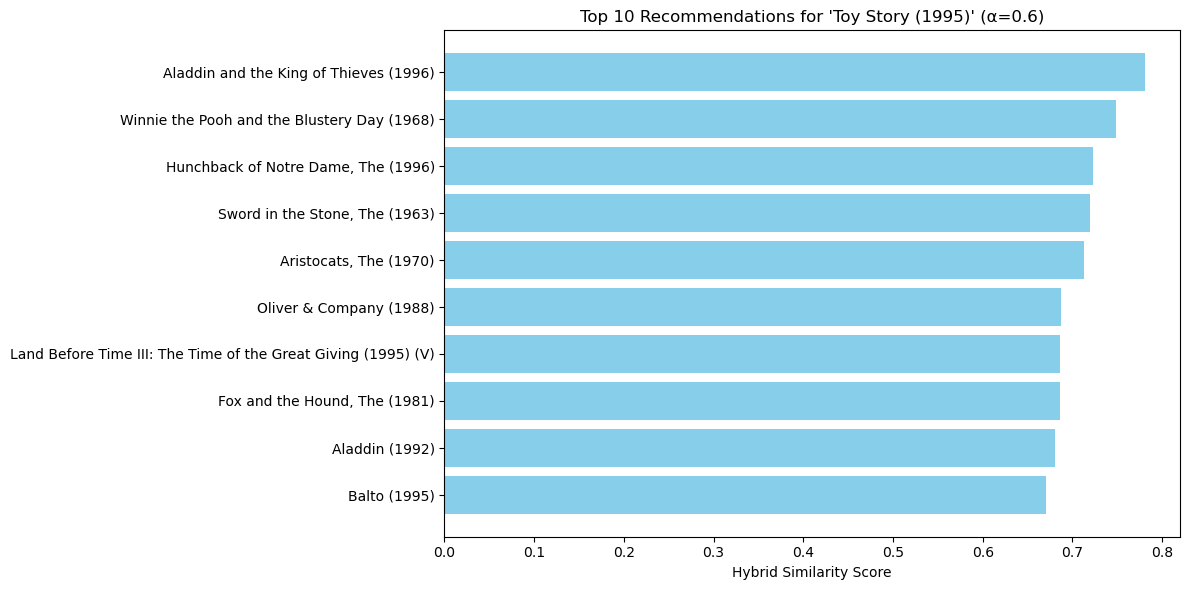

In [87]:
plot_hybrid_recommendations("Toy Story (1995)", alpha=0.6, top_n=10)


In [88]:
def get_hybrid_recommendations(title, alpha=0.5, top_n=10, verbose=False):
    if title not in indices or title not in collab_indices:
        if verbose: print("Title not in both indices.")
        return []

    idx_content = indices[title]
    idx_collab = collab_indices[title]

    shared_titles = list(set(indices.index) & set(collab_indices.index))
    shared_titles = [t for t in shared_titles if t != title]

    scores = []
    for t in shared_titles:
        try:
            idx_c = indices[t]
            idx_cf = collab_indices[t]
            content_sim = float(cosine_sim[idx_content][idx_c])
            collab_sim_score = float(collab_sim[idx_collab][idx_cf])
            hybrid_score = alpha * content_sim + (1 - alpha) * collab_sim_score
            scores.append((t, content_sim, collab_sim_score, hybrid_score))
        except Exception as e:
            if verbose:
                print(f"Skipping '{t}': {e}")
            continue

    scores = sorted(scores, key=lambda x: x[3], reverse=True)
    return scores[:top_n]


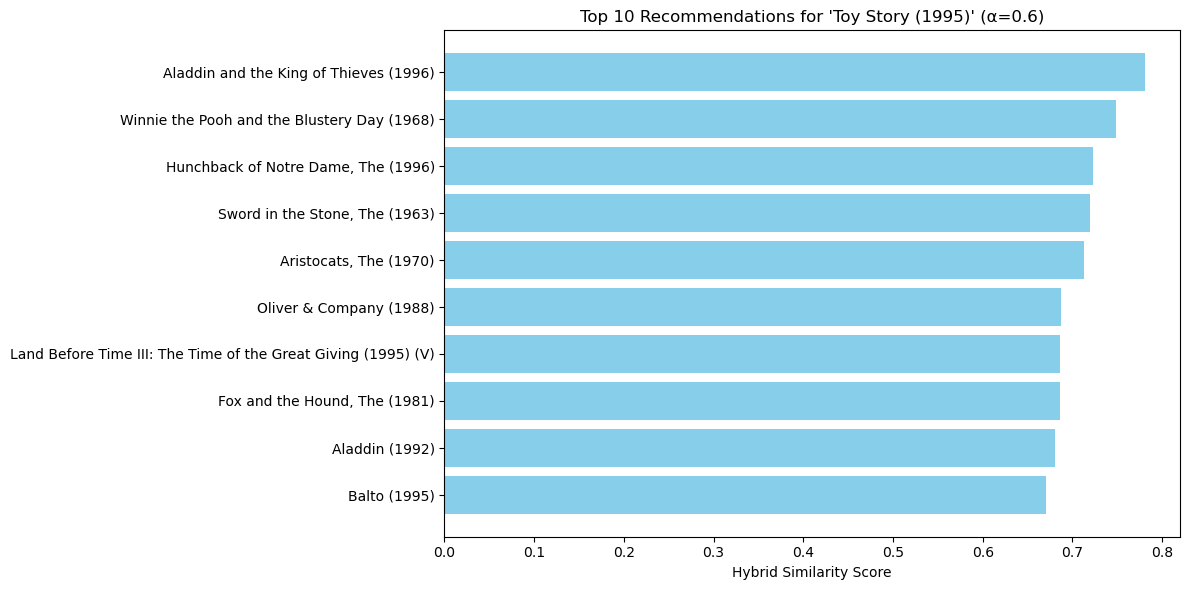

In [91]:
plot_hybrid_recommendations("Toy Story (1995)", alpha=0.6, top_n=10)


In [92]:
def plot_hybrid_recommendations(title, alpha=0.5, top_n=10):
    scores = get_hybrid_recommendations(title, alpha=alpha, top_n=top_n)
    scores = [s for s in scores if len(s) == 4]

    if len(scores) == 0:
        print(f"No recommendations found for '{title}'. Try a different title.")
        return

    titles, content_scores, collab_scores, hybrid_scores = zip(*scores)

    x = np.arange(len(titles))
    width = 0.25

    plt.figure(figsize=(14, 6))
    plt.bar(x - width, content_scores, width, label='Content-Based')
    plt.bar(x, collab_scores, width, label='Collaborative')
    plt.bar(x + width, hybrid_scores, width, label='Hybrid')

    plt.xticks(x, titles, rotation=45, ha='right')
    plt.ylabel('Similarity Score')
    plt.title(f"Top {top_n} Hybrid Recommendations for '{title}' (α={alpha})")
    plt.legend()
    plt.tight_layout()
    plt.show()

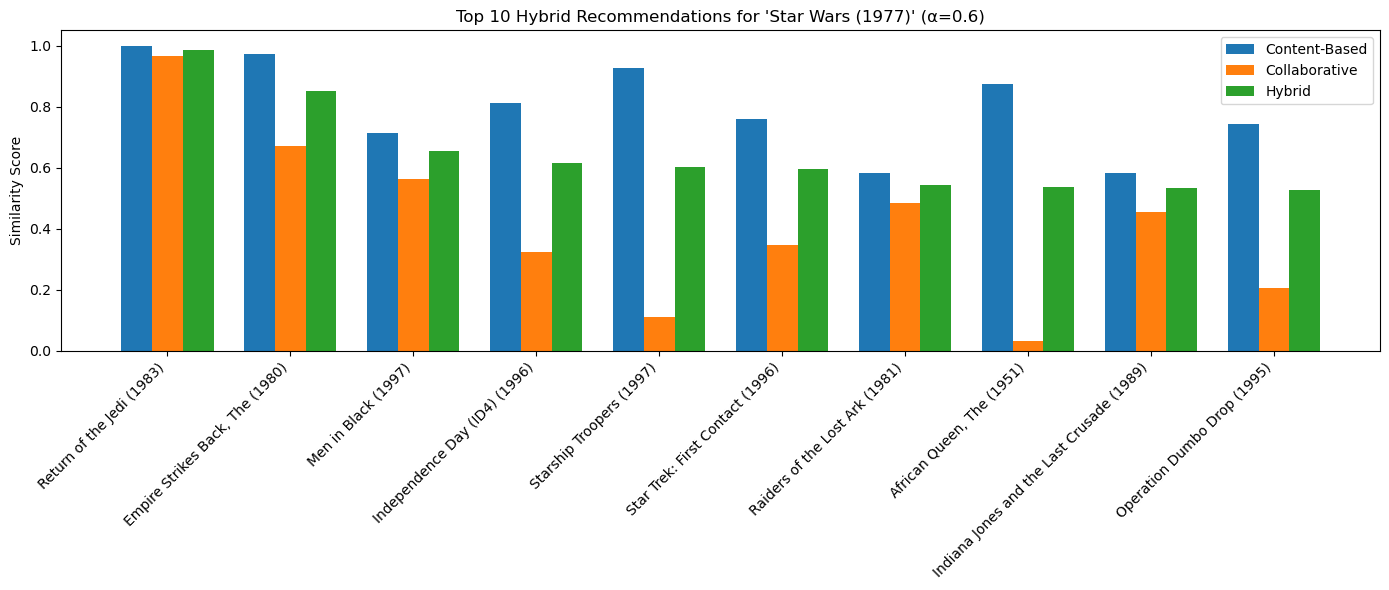

In [95]:
plot_hybrid_recommendations("Star Wars (1977)", alpha=0.6, top_n=10)
